In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/Users/subhransu/Downloads/ev battery_failure prediction Dataset.csv')

In [3]:
df


,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Ford,Mustang Mach-E,Truck,2022.0,Northvolt,NMC,NaN,AWD,290844.3,...,1.0,NaN,0.0,30.37,73.05,98.14,89.73,47.11,6748.0,0
1,EV100001,Tata,Tiago EV,Truck,2017.0,CATL,NCA,38.71,RWD,182239.5,...,0.0,1.0,0.0,67.94,82.50,NaN,NaN,55.38,5211.0,0
2,EV100002,Volkswagen,ID.3,Crossover,2016.0,BYD Battery,LFP,131.29,FWD,249369.3,...,0.0,1.0,0.0,74.84,90.33,60.02,86.84,74.54,4040.0,0
3,EV100003,NaN,Kona Electric,Sedan,2019.0,SK On,NMC,132.35,FWD,134830.2,...,NaN,0.0,0.0,46.94,56.69,66.43,93.93,31.69,NaN,0
4,EV100004,MG,ZS EV,SUV,2017.0,Guoxuan,LTO,25.72,AWD,158026.0,...,1.0,2.0,3.0,49.07,73.65,95.05,100.00,23.46,7290.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,EV119995,Volkswagen,ID.4,NaN,2023.0,Guoxuan,NCA,125.67,RWD,238002.7,...,3.0,0.0,0.0,34.58,51.30,89.22,94.26,42.17,8238.0,0
19996,EV119996,NaN,ID.4,Hatchback,2024.0,Panasonic,LMO,31.41,RWD,135664.1,...,0.0,0.0,1.0,34.68,28.89,89.69,94.97,48.42,10388.0,0
19997,EV119997,Renault,Megane E-Tech,Sedan,2018.0,CATL,NMC,27.23,AWD,132300.2,...,4.0,0.0,2.0,60.54,63.84,97.54,81.12,23.08,6027.0,0
19998,EV119998,Mercedes-Benz,EQE,Crossover,2017.0,Guoxuan,NMC,115.46,AWD,119023.9,...,0.0,1.0,0.0,41.17,81.07,90.90,82.90,32.15,5873.0,0


In [4]:
df.columns

Index(['vehicle_id', 'vehicle_brand', 'vehicle_model', 'vehicle_type',
       'manufacturing_year', 'battery_manufacturer', 'battery_chemistry',
       'battery_capacity_kwh', 'drive_type', 'odometer_km',
       'vehicle_age_years', 'fleet_or_private', 'battery_serial',
       'cycle_count', 'battery_health_percent', 'state_of_charge',
       'depth_of_discharge', 'state_of_health', 'cell_voltage_avg',
       'cell_voltage_std', 'pack_voltage', 'cell_temperature_avg',
       'cell_temperature_max', 'internal_resistance', 'charge_efficiency',
       'discharge_efficiency', 'remaining_capacity', 'capacity_loss_percent',
       'charging_cycles_last_month', 'fast_charge_ratio', 'slow_charge_ratio',
       'average_charge_power_kw', 'average_charging_time',
       'overnight_charging_ratio', 'home_charging_ratio',
       'charging_interruptions', 'overcharge_events', 'average_speed',
       'average_trip_distance', 'aggressive_acceleration_score',
       'hard_braking_score', 'regenerative

In [5]:
selected_columns = [
    'battery_capacity_kwh',
    'odometer_km',
    'vehicle_age_years',
    'cycle_count',
    'battery_health_percent',
    'state_of_charge',
    'depth_of_discharge',
    'state_of_health',
    'cell_voltage_std',
    'cell_temperature_max',
    'internal_resistance',
    'capacity_loss_percent',
    'charging_interruptions',
    'overcharge_events',
    'battery_failure'
]

df_model = df[selected_columns]

df_model.head()

,battery_capacity_kwh,odometer_km,vehicle_age_years,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_std,cell_temperature_max,internal_resistance,capacity_loss_percent,charging_interruptions,overcharge_events,battery_failure
0,NaN,290844.3,4.45,NaN,80.60,65.00,58.74,79.75,0.0046,27.87,0.506,19.40,2.0,1.0,0
1,38.71,182239.5,9.17,1425.0,61.24,43.32,35.23,60.72,0.0236,27.26,0.861,38.76,2.0,0.0,0
2,131.29,249369.3,10.17,NaN,62.35,68.37,59.60,62.71,NaN,53.79,0.720,37.65,1.0,1.0,0
3,132.35,134830.2,7.41,776.0,83.41,63.87,60.77,83.36,0.0167,53.12,0.351,16.59,3.0,0.0,0
4,25.72,158026.0,9.56,1117.0,78.49,46.59,37.54,76.97,0.0169,31.69,0.425,21.51,1.0,0.0,0


<Axes: xlabel='battery_health_percent', ylabel='Count'>

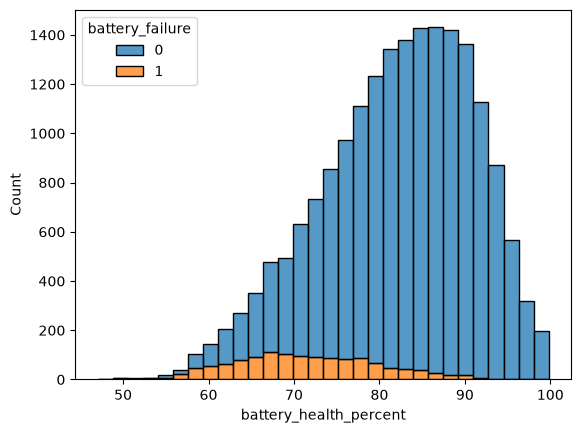

In [6]:
sns.histplot(data=df_model, x='battery_health_percent', hue='battery_failure', multiple='stack', bins=30)

<Axes: xlabel='battery_failure', ylabel='battery_health_percent'>

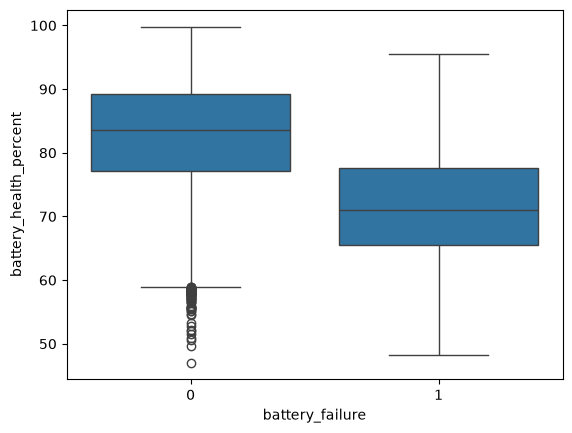

In [7]:
sns.boxplot(data=df_model, x='battery_failure', y='battery_health_percent')

<Axes: xlabel='battery_failure', ylabel='count'>

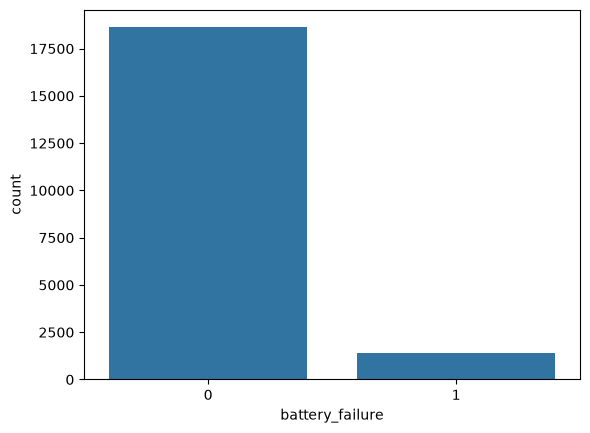

In [8]:
sns.countplot(data=df_model, x='battery_failure')

<Axes: xlabel='battery_failure', ylabel='count'>

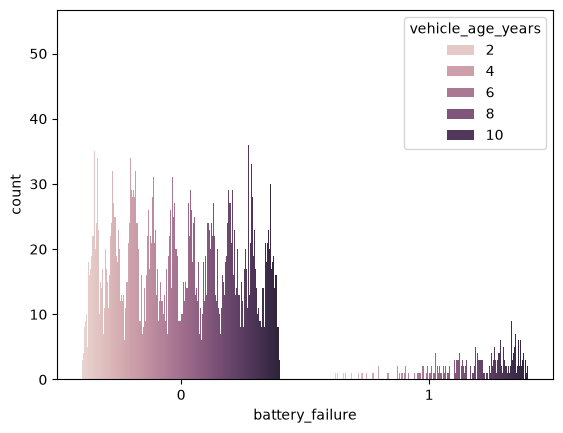

In [9]:
sns.countplot(data=df_model, x='battery_failure', hue='vehicle_age_years')

/var/folders/hz/t13jtbc557n1_913qg2rgrqh0000gn/T/ipykernel_12218/2091593090.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_model, x='vehicle_age_years', y='battery_health_percent', hue='battery_failure', ci=None)


<Axes: xlabel='vehicle_age_years', ylabel='battery_health_percent'>

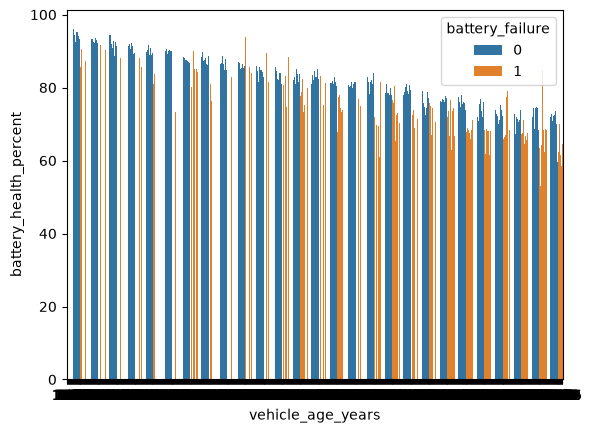

In [10]:
sns.barplot(data=df_model, x='vehicle_age_years', y='battery_health_percent', hue='battery_failure', ci=None)

<Axes: xlabel='battery_failure', ylabel='cell_voltage_std'>

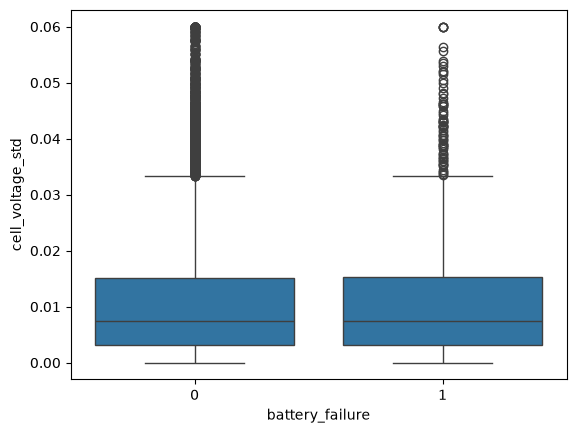

In [11]:
sns.boxplot(data=df_model, x='battery_failure', y='cell_voltage_std')

<Axes: xlabel='battery_failure', ylabel='overcharge_events'>

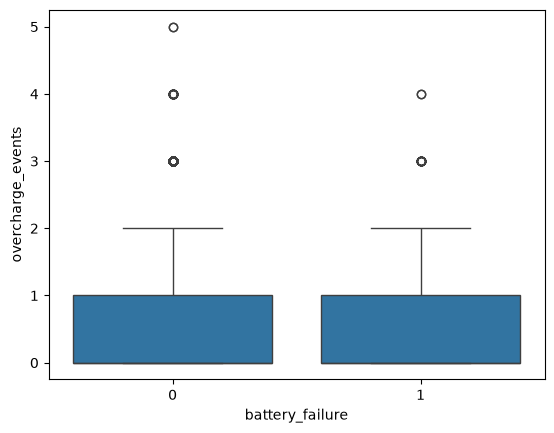

In [12]:
sns.boxplot(data=df_model, x='battery_failure', y='overcharge_events')

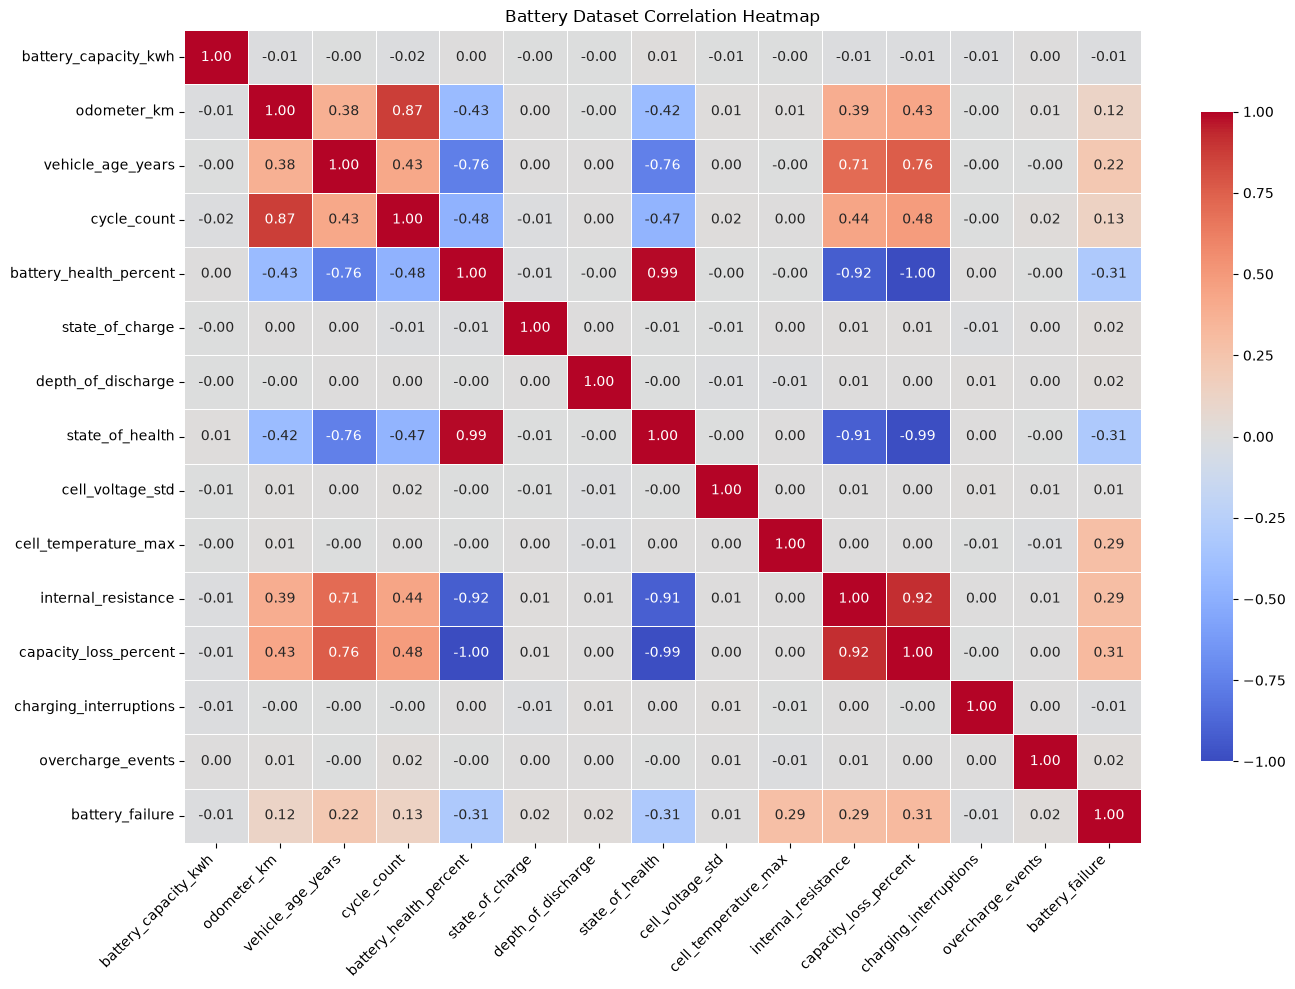

In [13]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df_model.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Battery Dataset Correlation Heatmap")
plt.tight_layout()
plt.show()


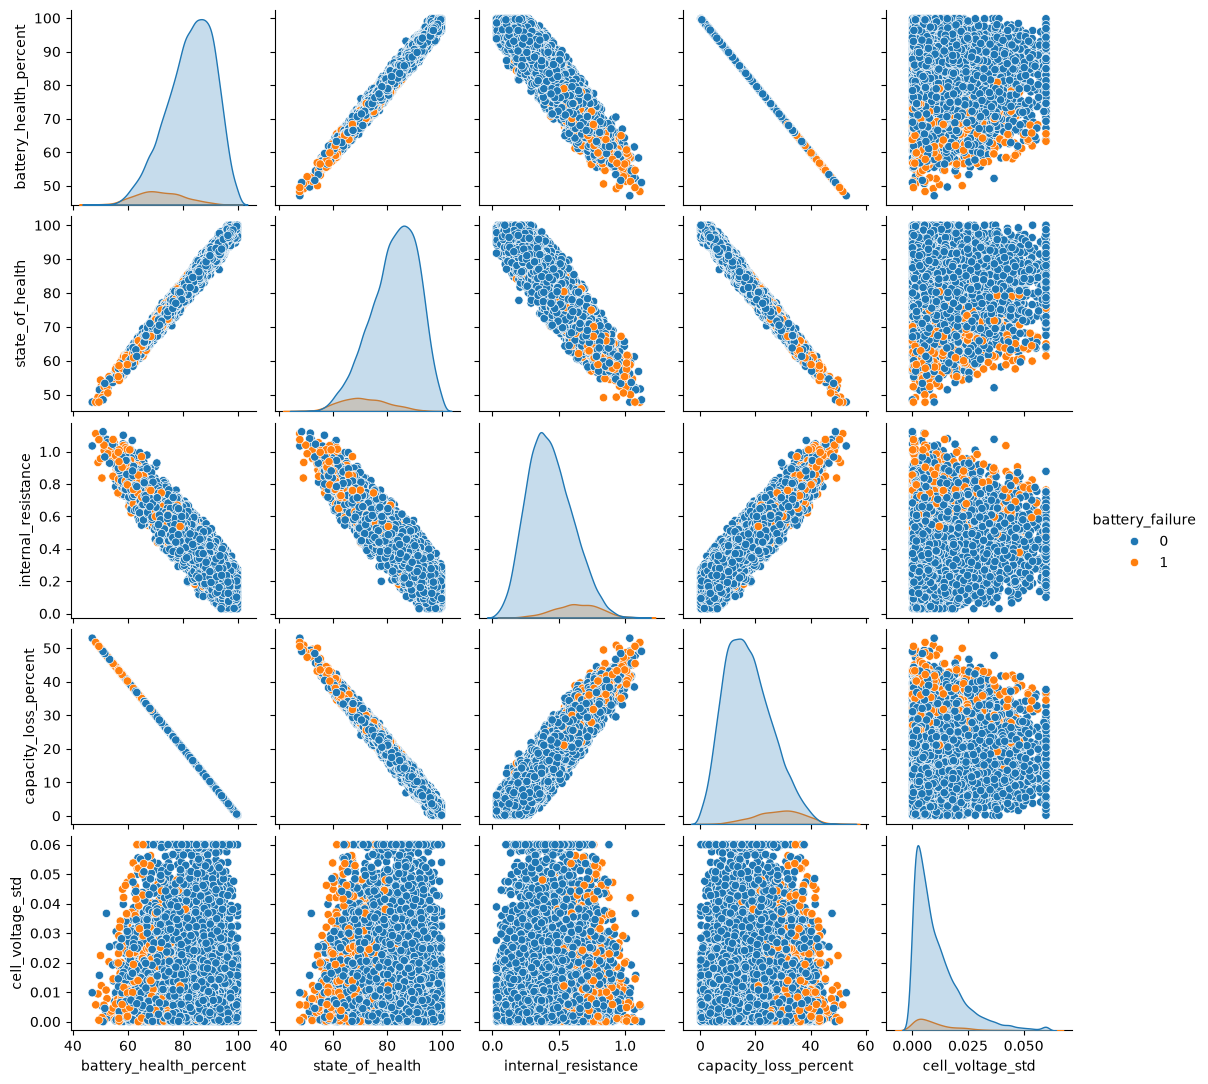

In [14]:
sns.pairplot(
    df_model[
        ['battery_health_percent', 'state_of_health', 'internal_resistance',
         'capacity_loss_percent', 'cell_voltage_std', 'battery_failure']
    ],
    hue='battery_failure',
    diag_kind='kde',
    height=2.2
)
plt.show()


In [15]:
df_model['battery_failure'].value_counts(normalize=True)

battery_failure
0    0.9308
1    0.0692
Name: proportion, dtype: float64

In [16]:
df_model.isnull().sum()

battery_capacity_kwh      690
odometer_km               866
vehicle_age_years         768
cycle_count               766
battery_health_percent    898
state_of_charge           964
depth_of_discharge        832
state_of_health           956
cell_voltage_std          856
cell_temperature_max      944
internal_resistance       798
capacity_loss_percent     956
charging_interruptions    964
overcharge_events         716
battery_failure             0
dtype: int64

In [30]:


target_col = 'battery_failure'
x=df_model.drop(columns=[target_col])
y=df_model[target_col]













numerical_cols = x.select_dtypes(include=['number']).columns.tolist()
categorical_cols = x.select_dtypes(exclude=['number']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['battery_capacity_kwh', 'odometer_km', 'vehicle_age_years', 'cycle_count', 'battery_health_percent', 'state_of_charge', 'depth_of_discharge', 'state_of_health', 'cell_voltage_std', 'cell_temperature_max', 'internal_resistance', 'capacity_loss_percent', 'charging_interruptions', 'overcharge_events']
Categorical columns: []


In [31]:

numeric_cols = df_model.select_dtypes(include=['number']).columns
for col in numeric_cols:
    df_model[col] = df_model[col].fillna(df_model[col].mean())


categorical_cols = df_model.select_dtypes(exclude=['number']).columns
for col in categorical_cols:
    if df_model[col].isnull().any():
        df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

In [32]:
df_model.isnull().sum()

battery_capacity_kwh      0
odometer_km               0
vehicle_age_years         0
cycle_count               0
battery_health_percent    0
state_of_charge           0
depth_of_discharge        0
state_of_health           0
cell_voltage_std          0
cell_temperature_max      0
internal_resistance       0
capacity_loss_percent     0
charging_interruptions    0
overcharge_events         0
battery_failure           0
dtype: int64

In [33]:
df_model.duplicated().sum()

np.int64(0)

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

In [37]:
numeric_pipeline=Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])
categorical_pipeline=Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])  



preprocessor=ColumnTransformer([
    ('num',numeric_pipeline,numerical_cols),
    ('cat',categorical_pipeline,categorical_cols)
])


model_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',RandomForestClassifier(n_estimators=100,random_state=42))
])


In [38]:
model_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['battery_capacity_kwh','odometer_km','vehicle_age_years',..., 'capacity_loss_percent','charging_interruptions','overcharge_events']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (defa

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred=model_pipeline.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

In [42]:
accuracy

0.94225

In [43]:
confusion_matrix(y_test, y_pred)

array([[3682,   41],
       [ 190,   87]])

In [45]:
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T

,precision,recall,f1-score,support
0,0.950930,0.988987,0.969585,3723.00000
1,0.679688,0.314079,0.429630,277.00000
accuracy,0.942250,0.942250,0.942250,0.94225
macro avg,0.815309,0.651533,0.699607,4000.00000
weighted avg,0.932146,0.942250,0.932193,4000.00000


In [46]:
import joblib
joblib.dump(model_pipeline, 'battery_failure_model.pkl')

['battery_failure_model.pkl']